<a href="https://colab.research.google.com/github/Sambuddha10/telco-churn-prediction/blob/main/notebooks/01_eda_and_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

url ="https://raw.githubusercontent.com/Sambuddha10/telco-churn-prediction/refs/heads/main/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values in each column:")
missing_values[missing_values > 0]

Missing values in each column:


,0


In [29]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after conversion:")
print(df["TotalCharges"].isnull().sum())

df[df["TotalCharges"].isnull()].head()

Missing values after conversion:
11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


In [30]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

TotalCharges data type: float64
Missing TotalCharges values: 0


In [31]:
churn_summary = pd.DataFrame({
    "Customer Count": df["Churn"].value_counts(),
    "Percentage": (df["Churn"].value_counts(normalize=True) * 100).round(2)
})

churn_summary

,Customer Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


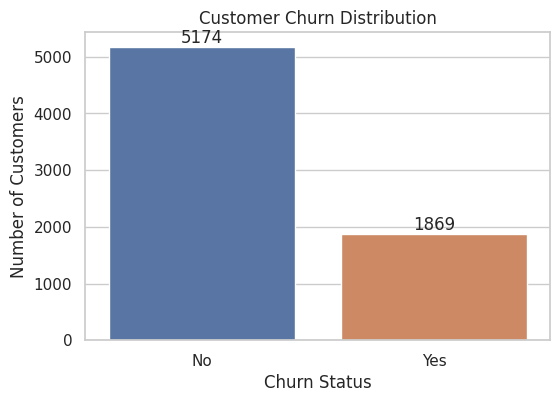

In [32]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Churn", hue="Churn", legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

# Exploratory Data Analysis

This section explores customer characteristics, account information, and services associated with customer churn.

In [33]:
churn_counts = df["Churn"].value_counts()

churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage (%)": churn_percentage
})

churn_summary

,Customer Count,Percentage (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


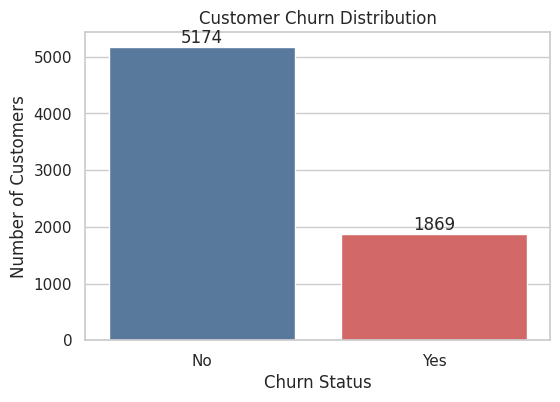

In [34]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=False,
    palette=["#4C78A8", "#E45756"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

## Churn rate by contract type

In [35]:
contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


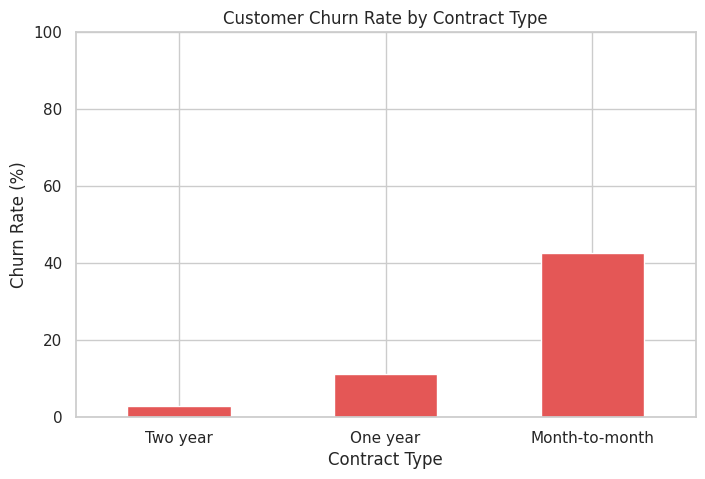

In [36]:
contract_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5),
    color="#E45756"
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

## Customer tenure and churn

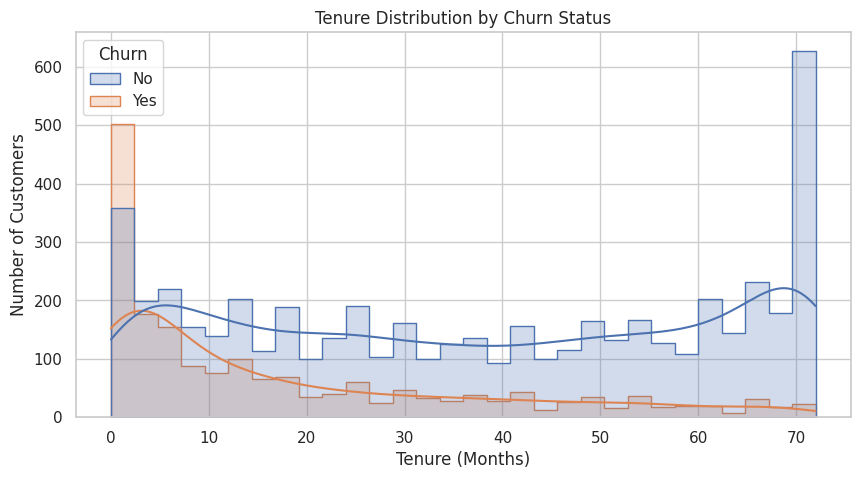

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step",
    stat="count",
    common_norm=False
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [38]:
tenure_summary = (
    df.groupby("Churn")["tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

tenure_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


## Monthly charges and churn

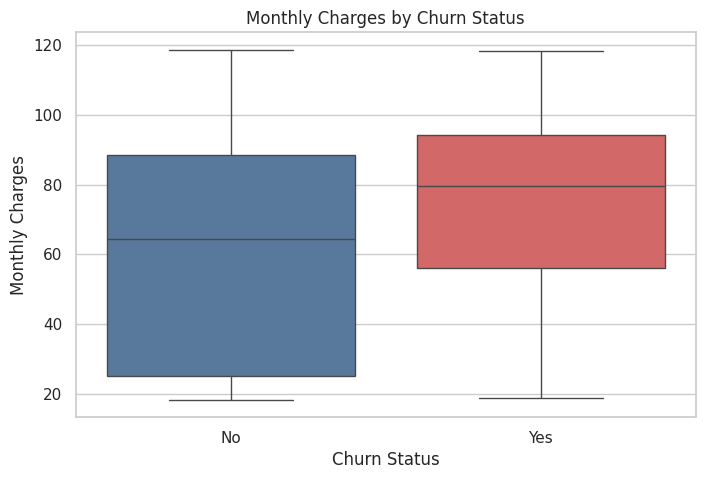

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    legend=False,
    palette=["#4C78A8", "#E45756"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()


In [40]:
charge_summary = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

charge_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


## Churn rate by payment method

In [41]:
payment_churn = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

payment_churn


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


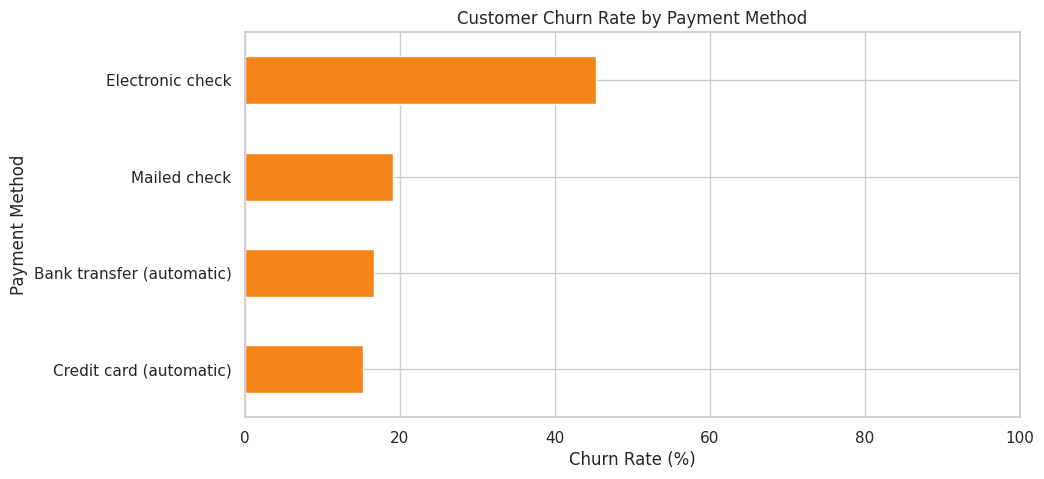

In [42]:
payment_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#F58518"
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.xlim(0, 100)
plt.show()


## Churn rate by internet service

In [43]:
internet_churn = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


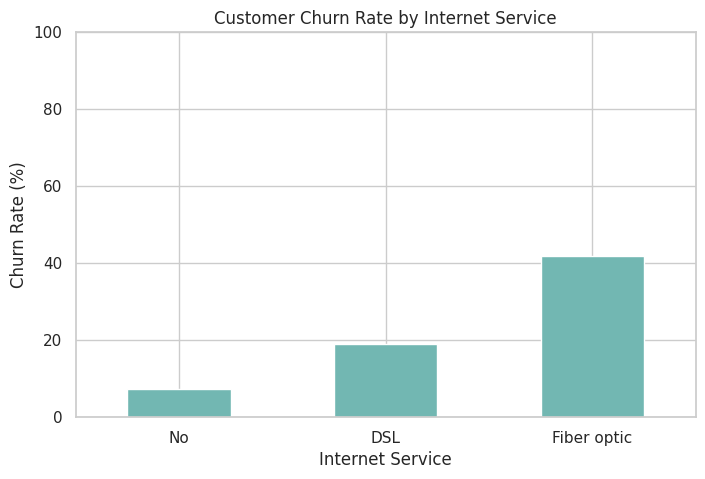

In [44]:
internet_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5),
    color="#72B7B2"
)

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

## Key EDA Findings

1. The dataset contains [TOTAL] customers. The churn rate is [CHURN RATE]%, which means the target classes are not perfectly balanced. Therefore, model evaluation will include recall, precision, F1-score, and ROC-AUC instead of accuracy alone.

2. Month-to-month contract customers have the highest churn rate at [VALUE]%, while [LOWEST-CONTRACT-TYPE] customers have the lowest churn rate at [VALUE]%. This indicates that longer commitments are associated with lower churn.

3. Churned customers have average tenure of [VALUE] months, compared with [VALUE] months for customers who stayed. Customers are most vulnerable to churn early in their relationship with the company.

4. The average monthly charge is [VALUE] for churned customers and [VALUE] for retained customers. This suggests pricing or service-value perception may be related to churn.

5. [PAYMENT METHOD] shows the highest churn rate. This segment should be investigated for billing experience, customer preferences, or plan characteristics.

6. [INTERNET SERVICE] customers show the highest churn rate. The company should investigate service quality, price competitiveness, and customer support for this group.

# Machine Learning Preprocessing and Baseline Model

This section prepares the telecom dataset for machine learning and trains a baseline Logistic Regression model to predict customer churn.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [47]:
# Copy the cleaned dataframe to keep the original data safe
model_df = df.copy()

# Convert churn labels into binary values
model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# customerID is only an identifier, not a useful predictive feature
X = model_df.drop(columns=["Churn", "customerID"])
y = model_df["Churn"]

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Feature dataset shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("\nTraining churn rate:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting churn rate:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training features shape: (5634, 19)
Testing features shape: (1409, 19)

Training churn rate:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Testing churn rate:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [49]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numeric features: 4
Number of categorical features: 15


In [50]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [51]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


In [52]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


In [53]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Score"]
)

metrics_df["Score"] = metrics_df["Score"].round(4)

metrics_df

NameError: name 'y_pred' is not defined

In [54]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [55]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Score"]
)

metrics_df["Score"] = metrics_df["Score"].round(4)

metrics_df

,Metric,Score
0,Accuracy,0.7381
1,Precision,0.5043
2,Recall,0.7834
3,F1 Score,0.6136
4,ROC-AUC,0.8413


In [56]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



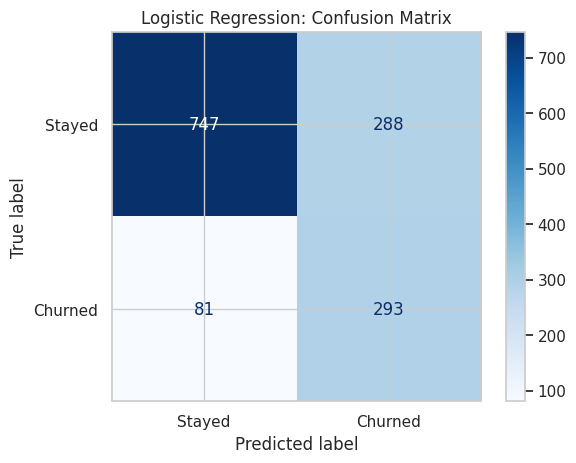

In [57]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

display.plot(cmap="Blues")
plt.title("Logistic Regression: Confusion Matrix")
plt.show()

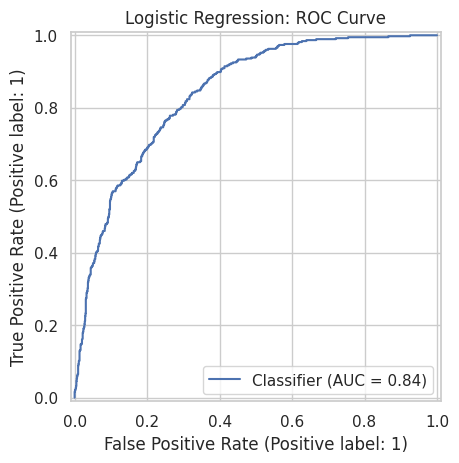

In [58]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("Logistic Regression: ROC Curve")
plt.show()

## Baseline Model Interpretation

The Logistic Regression model is used as the baseline because it is simple, fast, and interpretable.

- **Recall for churned customers** is important because a false negative means the business fails to identify a customer who is about to leave.
- **Precision for churned customers** matters because low precision would cause the company to spend retention offers on many customers who would not churn.
- **F1-score** summarizes the balance between precision and recall.
- **ROC-AUC** measures how well the model ranks churners above non-churners across possible classification thresholds.

The next stage will compare this baseline model with Random Forest and XGBoost, then select a model based on business priorities rather than accuracy alone.

# Tree-Based Model Comparison

This section compares Random Forest and XGBoost with the Logistic Regression baseline for telecom customer churn prediction.

In [59]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [60]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [61]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

pd.DataFrame([rf_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.7708,0.556,0.6765,0.6104,0.8363


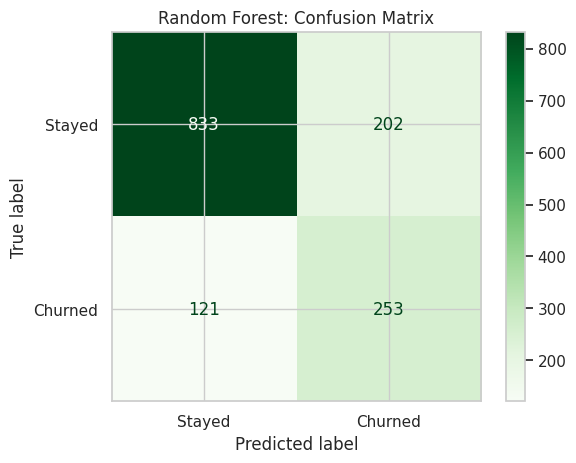

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Stayed", "Churned"],
    cmap="Greens"
)

plt.title("Random Forest: Confusion Matrix")
plt.show()

In [63]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Stayed customers in training set:", negative_count)
print("Churned customers in training set:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Stayed customers in training set: 4139
Churned customers in training set: 1495
scale_pos_weight: 2.77


In [64]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [65]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1 Score": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

pd.DataFrame([xgb_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.758,0.5306,0.7647,0.6265,0.8376


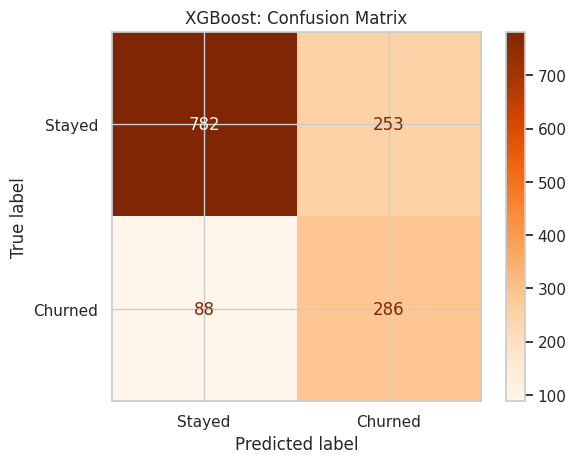

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Stayed", "Churned"],
    cmap="Oranges"
)

plt.title("XGBoost: Confusion Matrix")
plt.show()

In [67]:
logistic_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

comparison_df = pd.DataFrame([
    logistic_metrics,
    rf_metrics,
    xgb_metrics
])

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8413
1,XGBoost,0.7580,0.5306,0.7647,0.6265,0.8376
2,Random Forest,0.7708,0.5560,0.6765,0.6104,0.8363


<Figure size 800x600 with 0 Axes>

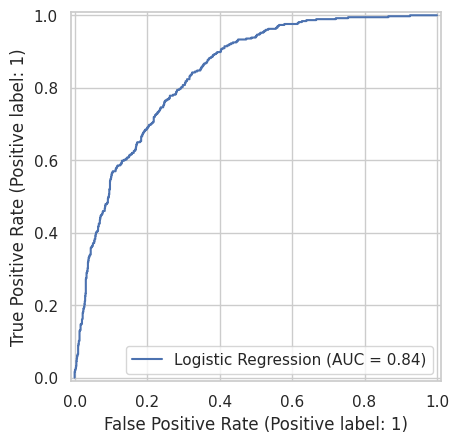

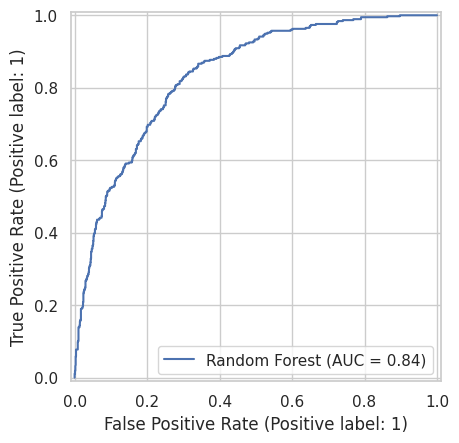

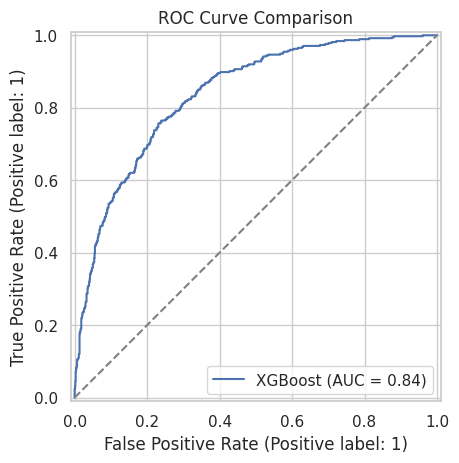

In [68]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.show()

## Model Selection

The final model will be selected based on the business objective: identifying customers at risk of churn.

- ROC-AUC measures overall ability to rank churners above retained customers.
- Recall measures how many actual churners the model successfully identifies.
- Precision measures how many predicted churners actually churn.
- F1-score balances precision and recall.

The preferred model should have strong ROC-AUC and F1-score, while maintaining a recall level that supports proactive retention campaigns. The final choice should not be based on accuracy alone.